In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import krippendorff as kd
from sklearn.metrics import accuracy_score


In [6]:
labels = pd.read_csv('/data/archief/AMC-data/Barrett/LANS/lans_train_labels_with_ind_final.csv')
cons = labels[["block_id", "dx"]]
cons = cons[["block_id", "dx"]].replace({1: 0, 2: np.nan, 3: 1, 4: 2})
cons = cons.dropna(subset=["dx"])


In [7]:
rater_labels = labels.loc[:,"p53":]
rater_labels = rater_labels.drop(["p53"], axis=1).replace({1: 0, 2: np.nan, 3: 1, 4: 2})
rater_labels = pd.concat([labels["block_id"], rater_labels], axis=1)

In [8]:
rater_labels.iloc[:,1]

0       0.0
1       0.0
2       0.0
3       0.0
4       1.0
       ... 
1887    0.0
1888    0.0
1889    0.0
1890    0.0
1891    0.0
Name: path_1, Length: 1892, dtype: float64

202

In [37]:
basis = {}
results = []
acc_individual = []
acc_consensus = []
difference = []

for path in range(1, 4):
    for fold in range(1, 6):
        df = pd.read_csv(f'/data/archief/AMC-data/Barrett/experiments/jans_experiments/final_Pathologist_{path}_fold_{fold}/results.csv')
        basis[(path, fold, "df")] = df
        basis[(path, fold, "individual_labels")] = rater_labels[rater_labels["block_id"].isin(df["block_id"])].iloc[:,path].reset_index(drop=True)
        basis[(path, fold, "predictions")] = df["pred_class"]
        basis[(path, fold, "consensus_labels")] = cons[cons["block_id"].isin(df["block_id"])]["dx"].reset_index(drop=True)
        #remark: no particular reason for both dict AND list, just the iteration of implementations



        results.append({
            "path": path,
            "fold": fold,
            "accuracy_individual": accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            ),
            "accuracy_consensus": accuracy_score(
                basis[(path, fold, "consensus_labels")],
                basis[(path, fold, "predictions")]
            ),
            "difference": accuracy_score(
                basis[(path, fold, "consensus_labels")],
                basis[(path, fold, "predictions")]
            ) - accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            ),
            "samples": df["samples"].values[0]
        })
results = pd.DataFrame(results)


In [40]:
results_agg = pd.DataFrame()
results_agg[["mean_acc_ind", "mean_acc_cons", "diff_means"]] = results.groupby(["path"])[["accuracy_individual", "accuracy_consensus", "difference"]].mean()
results_agg["min_ind"] = results.groupby(["path"])[["accuracy_individual"]].min()
results_agg["max_ind"] = results.groupby(["path"])[["accuracy_individual"]].max()
results_agg["min_cons"] = results.groupby(["path"])[["accuracy_consensus"]].min()
results_agg["max_cons"] = results.groupby(["path"])[["accuracy_consensus"]].max()
results_agg["samples"] = results.groupby(["path"])[["samples"]].max()

In [41]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
results_agg["normalized_difference"] = scaler.fit_transform(np.array(results_agg["diff_means"]).reshape(-1, 1))
results_agg

,mean_acc_ind,mean_acc_cons,diff_means,min_ind,max_ind,min_cons,max_cons,samples,normalized_difference
path,,,,,,,,,
1,0.744296,0.769709,0.025413,0.713376,0.783439,0.757962,0.778481,158,1.000000
2,0.830911,0.836764,0.005853,0.806569,0.849817,0.817518,0.849817,274,0.000000
3,0.759894,0.783632,0.023738,0.702970,0.806931,0.747525,0.826733,203,0.914357


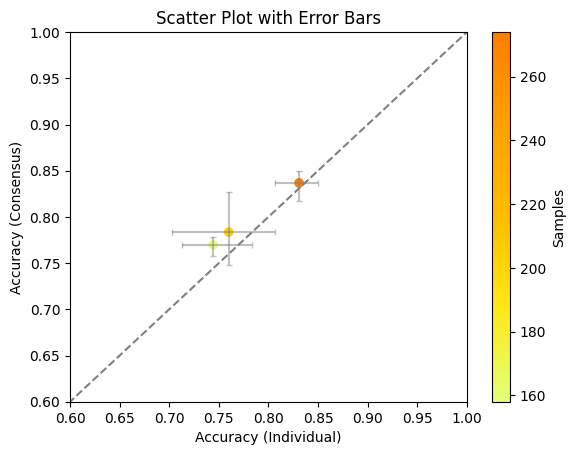

In [58]:
plt.scatter(results_agg["mean_acc_ind"], results_agg["mean_acc_cons"], c=results_agg["samples"], cmap='Wistia')
plt.errorbar(results_agg["mean_acc_ind"], results_agg["mean_acc_cons"], xerr=[results_agg["mean_acc_ind"] - results_agg["min_ind"], results_agg["max_ind"] - results_agg["mean_acc_ind"]], yerr=[results_agg["mean_acc_cons"] - results_agg["min_cons"], results_agg["max_cons"] - results_agg["mean_acc_cons"]], fmt=" ", ecolor="grey", capsize=2, alpha=0.5)
plt.xlabel("Accuracy (Individual)")
plt.ylabel("Accuracy (Consensus)")
plt.ylim(0.6, 1)
plt.xlim(0.6, 1)
plt.title("Scatter Plot with Error Bars")
plt.colorbar(label='Samples')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.show()


In [13]:
accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            )

0.806930693069307

In [14]:
basis = {}
results_per_class = []
acc_individual = []
acc_consensus = []
difference = []

for path in range(1, 4):
    for fold in range(1, 6):
            df = pd.read_csv(f'/data/archief/AMC-data/Barrett/experiments/jans_experiments/final_Pathologist_{path}_fold_{fold}/results.csv')
            basis[(path, fold, "df")] = df
            basis[(path, fold, "individual_labels")] = rater_labels[rater_labels["block_id"].isin(df["block_id"])].iloc[:,path].reset_index(drop=True)
            basis[(path, fold, "predictions")] = df["pred_class"]
            basis[(path, fold, "consensus_labels")] = cons[cons["block_id"].isin(df["block_id"])]["dx"].reset_index(drop=True)

            results_temp = ({
                "path": path,
                "fold": fold,
            })

            for n_class in [0,1,2]:
                results_temp[f"accuracy_individual_class_{n_class}"] = accuracy_score(
                        basis[(path, fold, "individual_labels")][basis[(path, fold, "individual_labels")] == n_class],
                        basis[(path, fold, "predictions")][basis[(path, fold, "individual_labels")] == n_class]
                )
                results_temp[f"accuracy_consensus_class_{n_class}"] = accuracy_score(
                        basis[(path, fold, "consensus_labels")][basis[(path, fold, "consensus_labels")] == n_class],
                        basis[(path, fold, "predictions")][basis[(path, fold, "consensus_labels")] == n_class]
                )

            results_per_class.append(results_temp)


results_per_class = pd.DataFrame(results_per_class)


In [15]:
results_per_class_agg = pd.DataFrame()
for n_class in [0,1,2]:
    results_per_class_agg[f"mean_acc_ind_class_{n_class}"] = results_per_class.groupby(["path"])[[f"accuracy_individual_class_{n_class}"]].mean()
    results_per_class_agg[f"mean_acc_cons_class_{n_class}"] = results_per_class.groupby(["path"])[[f"accuracy_consensus_class_{n_class}"]].mean()

results_per_class_agg

,mean_acc_ind_class_0,mean_acc_cons_class_0,mean_acc_ind_class_1,mean_acc_cons_class_1,mean_acc_ind_class_2,mean_acc_cons_class_2
path,,,,,,
1,0.875977,0.916945,0.653395,0.691506,0.357143,0.360096
2,0.925024,0.924242,0.782821,0.779172,0.601760,0.656994
3,0.881427,0.890906,0.667165,0.664410,0.650535,0.788802


# Agreement rater vs. virtual rater

In [31]:
agreement_rater_virtual = []

for path in range(1, 4):
    for fold in range(1,6):
            real_vs_virtual = pd.DataFrame(columns=["real", "virtual"])
            real_vs_virtual["real"] = basis[(path, fold, "individual_labels")]
            real_vs_virtual["virtual"] = basis[(path, fold, "predictions")]
            agreement_nom = kd.alpha(real_vs_virtual.T.values, level_of_measurement="nominal", value_domain=[0, 1.0, 2.0])
            agreement_ord = kd.alpha(real_vs_virtual.T.values, level_of_measurement="ordinal", value_domain=[0, 1.0, 2.0])
            accuracy = accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            )
            dict_temp = {
                "path": path,
                "fold": fold,
                "alpha_nom": agreement_nom,
                "alpha_ord": agreement_ord,
                "accuracy": accuracy
            }
            agreement_rater_virtual.append(dict_temp)
agreement_rater_virtual = pd.DataFrame(agreement_rater_virtual)
agreement_rater_virtual_agg = agreement_rater_virtual.groupby(["path"])[["alpha_nom", "alpha_ord", "accuracy"]].mean()
agreement_rater_virtual_agg

,alpha_nom,alpha_ord,accuracy
path,,,
1,0.532553,0.653584,0.744296
2,0.710737,0.811363,0.830911
3,0.613181,0.739256,0.759894


# Pairwise accuracy and agreement between virtual raters

### TODO: ensemble to have prediction over all folds

In [ ]:
pairwise_corr = pd.DataFrame(columns=[range(1,21)], index=[range(1,21)])

for i in range(1,21):
    for j in range(1,21):
        if i == j:
            pairwise_corr.loc[i,j] = 1
            continue
        i_df = pd.read_csv(f'/data/archief/AMC-data/Barrett/experiments/jans_experiments/final_Pathologist_{path}_fold_{fold}/results.csv')

        



        if len(pairwise_df[pairwise_df.isna().any(axis=1)]) == len(pairwise_df):
            pairwise_corr.loc[i,j] = np.nan
        else:
            pairwise_corr.loc[i,j] = kd.alpha(pairwise_df.T.values, level_of_measurement="nominal", value_domain=[np.nan, 1.0, 2.0, 3.0, 4.0])
            

In [33]:
df

,block_id,label,p53_label,p53_available,pred_class,samples,logit_NDBE,prob_NDBE,validation_samples_class_NDBE,logit_LGD,prob_LGD,validation_samples_class_LGD,logit_HGD,prob_HGD,validation_samples_class_HGD
0,RL-0007-II,1,0,1,1,202,-3.413410,0.005117,91,1.315303,0.579031,68,0.984277,0.415852,43
1,RL-0014-I,0,5,0,0,202,2.610978,0.952785,91,-0.416554,0.046148,68,-4.183549,0.001067,43
2,RL-0025-I,0,5,0,0,202,2.480777,0.973090,91,-1.230367,0.023792,68,-3.262487,0.003118,43
3,RL-0025-II,2,0,1,2,202,-3.266875,0.006209,91,0.793329,0.360051,68,1.358720,0.633739,43
4,RL-0026-IV,0,1,1,0,202,3.002045,0.956153,91,-0.088293,0.043492,68,-4.896117,0.000355,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,RL-0986-II,0,1,1,0,202,0.231374,0.547042,91,-0.260976,0.334346,68,-1.297288,0.118613,43
198,RL-0988-II,0,1,1,0,202,2.518822,0.941315,91,-0.275562,0.057564,68,-4.214460,0.001121,43
199,RL-0991-II,0,5,0,0,202,1.857521,0.848461,91,0.122314,0.149638,68,-4.243152,0.001902,43
200,RL-0997-I,2,0,0,2,202,-2.735864,0.010007,91,-0.124821,0.136221,68,1.710561,0.853772,43


# Pairwise agreement between virtual raters